In [ ]:
!pip install librosa pydub soundfile matplotlib

Convert mp3 to wav

In [3]:
from pydub import AudioSegment
import os

for file in os.listdir("/content"):
  # print(f"File name is : {file}")
  if file.endswith(".mp3"):
    mp3_path = os.path.join("/content",file)
    wav_path = mp3_path.replace(".mp3",".wav")
    audio = AudioSegment.from_mp3(mp3_path)
    audio = audio.set_frame_rate(16000)
    audio = audio.set_channels(1)
    audio.export(wav_path,format="wav")
print("mp3 to wav conversion completed !")



mp3 to wav conversion completed !


Load One Audio File

In [4]:
import librosa
y,sr = librosa.load(
    "/content/h1.wav",
    sr=16000
)
print("Sample Rate : ",sr)
print("Shape : ",y.shape)



# sr (Sample Rate): How many times per second the audio is measured (16,000 Hz).
# y (Audio Time Series): A 1D array of those measurements, capturing the shape of the sound wave over time.

Sample Rate :  16000
Shape :  (57984,)


Load One Audio File

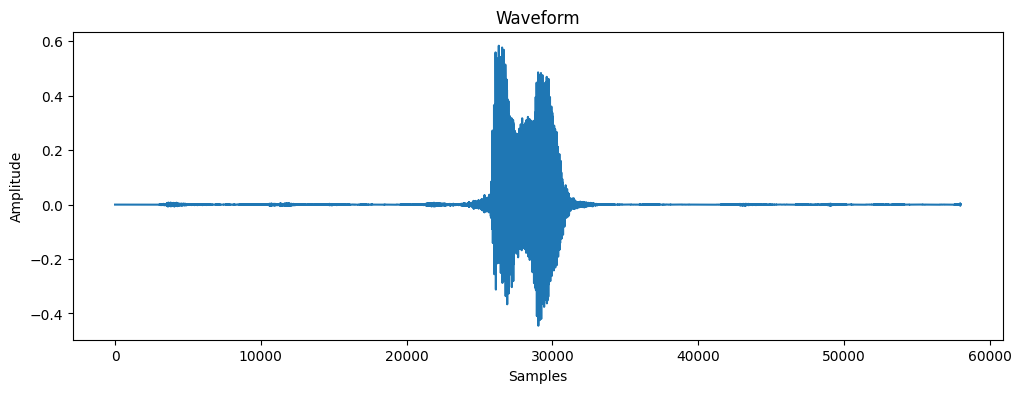

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))

plt.plot(y)
plt.title("Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

Listen To Audio

In [6]:
from IPython.display import Audio

Audio(y, rate=sr)

Create Spectrogram

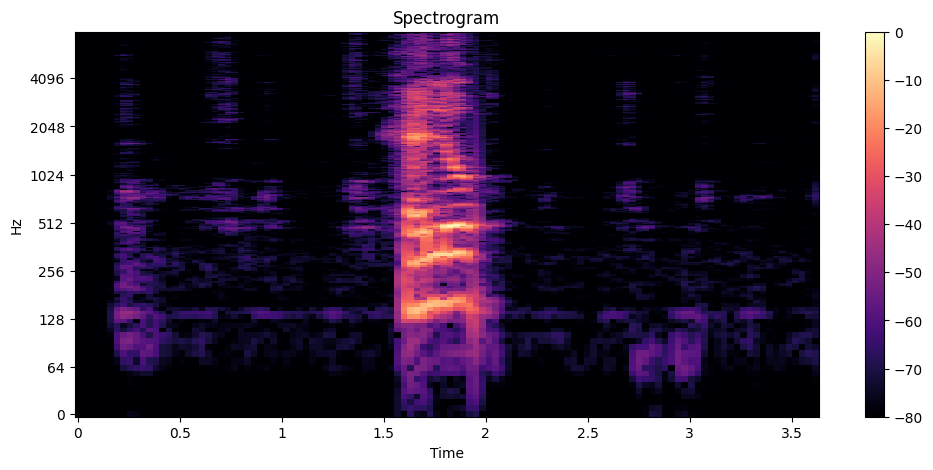

In [7]:
import numpy as np
import librosa.display

D = librosa.amplitude_to_db(
    np.abs(librosa.stft(y)),
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    D,
    sr=sr,
    x_axis='time',
    y_axis='log'
)

plt.colorbar()

plt.title("Spectrogram")

plt.show()

Create MFCC

In [8]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

print(mfcc.shape)

(13, 114)


Visualize MFCC

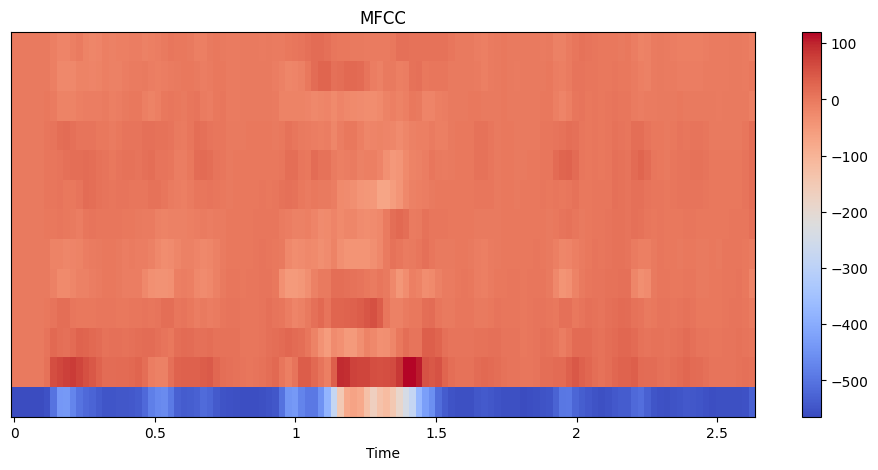

In [9]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC")

plt.show()

# Extract Features From ALL Files

In [10]:
import os
import librosa
import numpy as np

X = []
y_labels = []

label_map = {
    "h": "hello",
    "y": "yes",
    "n": "no",
    "s": "stop",
    "g": "go"
}

for file in os.listdir("/content"):

    if file.endswith(".wav"):

        filepath = os.path.join("/content", file)

        audio, sr = librosa.load(
            filepath,
            sr=16000
        )

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=13
        )

        feature = np.mean(
            mfcc,
            axis=1
        )

        X.append(feature)

        prefix = file[0]

        y_labels.append(
            label_map[prefix]
        )

X = np.array(X)

print(X.shape)
print(y_labels)

(15, 13)
['hello', 'no', 'no', 'yes', 'stop', 'go', 'hello', 'stop', 'yes', 'yes', 'hello', 'go', 'go', 'stop', 'no']


# Encode Labels

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y_labels)

print(y)
print(encoder.classes_)

[1 2 2 4 3 0 1 3 4 4 1 0 0 3 2]
['go' 'hello' 'no' 'stop' 'yes']


## Architecture

MP3 Files
    ↓
WAV Conversion
    ↓
Load Audio
    ↓
Waveform
    ↓
Spectrogram
    ↓
MFCC
    ↓
Feature Matrix X

In [13]:
print(X.shape)

(15, 13)


## Train Test split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 12
Testing Samples: 3


## Train Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Complete")

Training Complete


## Model Evaluations

In [16]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


## Actual Predictions

In [17]:
for actual, predicted in zip(y_test, predictions):

    print(
        "Actual:",
        encoder.inverse_transform([actual])[0],
        "| Predicted:",
        encoder.inverse_transform([predicted])[0]
    )

Actual: yes | Predicted: yes
Actual: go | Predicted: go
Actual: hello | Predicted: hello


Confusion Matrix

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[1 0 0]
 [0 1 0]
 [0 0 1]]


## Save model

In [19]:
import joblib

joblib.dump(
    model,
    "speech_model.pkl"
)

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

print("Model Saved")

Model Saved


## Load Saved Model

In [20]:
import joblib

loaded_model = joblib.load(
    "speech_model.pkl"
)

loaded_encoder = joblib.load(
    "label_encoder.pkl"
)

print("Loaded Successfully")

Loaded Successfully


## Predict the audio file

In [1]:
import librosa
import numpy as np

audio, sr = librosa.load(
    "/content/h2.wav",
    sr=16000
)

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

feature = np.mean(
    mfcc,
    axis=1
)

feature = feature.reshape(
    1,
    -1
)

prediction = loaded_model.predict(
    feature
)

word = loaded_encoder.inverse_transform(
    prediction
)

print("Predicted Word:", word[0])

/tmp/ipykernel_850/4244015350.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: '/content/h2.wav'